# Example notebook for NV center in diamond Lindblad master equation simulations.

## Importing Packages

In [19]:
# !pip install qutip
# Generally useful packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure, show, grid, tight_layout
plt.rcParams.update({'font.sans-serif':'DejaVu Sans'})

# Make the Jupyter Notebook fill 90 percent of the screen (nerd_mode)
from IPython.display import display, HTML
display(HTML("<style>:root { --jp-notebook-max-width: 90% !important; }</style>"))

# qutip, the thing that actually does the numerics
# qutip documentation here: https://qutip.org/
from qutip import *

## Defining the Hamiltonian. Using a 7-level description.

In [20]:
# Defining basis functions for the 7 level basis
# gs - ground electronic state, 0- m=0, m1- m=-1, p1- m=+1
# es - excited electronic state, 0- m=0, m1- m=-1, p1- m=+1
# shelf - singlet shelving state

gs_0 = basis(7,1)
gs_m1 = basis(7,2)
gs_p1 = basis(7,0)
es_0 = basis(7,4)
es_m1 = basis(7,5)
es_p1 = basis(7,3)
shelf_state = basis(7,6)




# No applied magnetic field - all the spin states are degenerate
# Units: [us/MHz]
# NV center optical transition energy: 637.1 nm ~ 1.945 eV ~ 470.8 THz = 4.708 x 10^(8) MHz
# placed the shelving state halfway between the ground and excited states, which is, not true
# factor of 2*pi to make this into an angular frequency
H_0 = 2 * np.pi * (4.708E8*es_p1*es_p1.dag()
                    + 4.708E8*es_0*es_0.dag()
                    + 4.708E8*es_m1*es_m1.dag()
                    + 0.5*4.708E8*shelf_state*shelf_state.dag())

## Define an initial density matrix

In [21]:
# assuming initial density is thermal (1/3 in each of the three ground states)

row1=[1/3,0,0,0,0,0,0] #row 1-3 are the GS states
row2=[0,1/3,0,0,0,0,0]
row3=[0,0,1/3,0,0,0,0]
row4=[0,0,0,0,0,0,0] #row 4-6 are the ES states
row5=[0,0,0,0,0,0,0]
row6=[0,0,0,0,0,0,0]
row7=[0,0,0,0,0,0,0] # row 7 is the shelving state

rho_0=Qobj(np.array([row1, row2, row3, row4, row5, row6, row7]))

## Definte transition rates

In [22]:
# Define transition rates

rate_laser = 1/0.1 #rate of excitation
rate_eg = 1/0.012 #rate of relaxation from the ES to GS (give off a photon)
rate_isc = 1/0.045 #rate of relaxing from the ES to the shelve state
rate_sg = 1/0.300 #rate of relaxing from the shelve state to the ground state
rate_T1 = 1E-99 # rate of T1 process happening in the GS/ES prob= e^-t/T1. Usually T1 is in ms, we just make T1 rate very small here

# where are these numbers from - generally, Lucio Robledo's work - https://iopscience.iop.org/article/10.1088/1367-2630/13/2/025013/pdf

## Define collapse operators

In [23]:
dim = 7

# Laser Pumping
cop_03 = np.sqrt(rate_laser)*es_0*gs_0.dag() # excite gs_p1 to es_p1
cop_14 = np.sqrt(rate_laser)*es_m1*gs_m1.dag() # excite gs_0 to es_0
cop_25 = np.sqrt(rate_laser)*es_p1*gs_p1.dag() # excite gs_m1 to es_m1

# T1 processes
cop_01 = np.sqrt(rate_T1)*gs_m1*gs_0.dag() # random spin flip from gs_m1 to gs_0
cop_12 = np.sqrt(rate_T1)*gs_p1*gs_m1.dag()
cop_20 = np.sqrt(rate_T1)*gs_0*gs_p1.dag()

cop_10 = cop_01.dag()
cop_21 = cop_12.dag()
cop_02 = cop_20.dag()

# Spontaneous emission
cop_30 = np.sqrt(rate_eg)*gs_0*es_0.dag() # relaxation from es_0 to gs_0 (all transitions are spin conserving)
cop_41 = np.sqrt(rate_eg)*gs_m1*es_m1.dag()
cop_62 = np.sqrt(rate_eg)*gs_p1*es_p1.dag()

# ISC, note that the spin-0 rate for ISC is about a tenth of the high-spin ISC
cop_47 = np.sqrt(rate_isc/10)*shelf_state*es_0.dag() #shelve state only has one spin (m=0)
cop_57 = np.sqrt(rate_isc)*shelf_state*es_m1.dag()
cop_67 = np.sqrt(rate_isc)*shelf_state*es_p1.dag()

cop_70 = np.sqrt(rate_sg)*gs_0*shelf_state.dag() # shelve state to GS
cop_72 = np.sqrt(rate_sg)*gs_m1*shelf_state.dag()
cop_73 = np.sqrt(rate_sg)*gs_p1*shelf_state.dag()

cops = [cop_03, cop_14, cop_25, cop_01, cop_12, cop_20, cop_10, cop_21, cop_02, cop_30, cop_41, cop_62, cop_47, cop_57, cop_67, cop_70, cop_72, cop_73]


## defining an 7x7 Sz operator

In [24]:
row1=[1,0,0,0,0,0,0] #row 1-3 are the GS states
row2=[0,0,0,0,0,0,0]
row3=[0,0,-1,0,0,0,0]
row4=[0,0,0,0,0,0,0] #row 4-6 are the ES states
row5=[0,0,0,0,0,0,0]
row6=[0,0,0,0,0,0,0]
row7=[0,0,0,0,0,0,0] # row 7 is the shelving state

Sz = Qobj(np.array([row1, row2, row3, row4, row5, row6, row7]))

## defining functions for state evolution under optical pumping

In [25]:
# evolution of state while optically pumping (outputs the expectation value of the expect_op)
def evolve_optical_pumping(rho_0, H, t_end, num_pts, c_op_list, expect_op):
  tlist = np.linspace(0, t_end, num_pts)
  output = mesolve(H, rho_0, tlist, c_op_list, [expect_op])

  return output

# evolution of state while optically pumping (outputs the density matrices / state list)
def evolve_optical_pumping_ds(rho_0, H, t_end, num_pts, c_op_list):
  tlist = np.linspace(0, t_end, num_pts)
  output = mesolve(H, rho_0, tlist, c_op_list)

  return output

## Example: optically pump for 3 us, 1000 points, return density matrix

In [26]:
output = evolve_optical_pumping_ds(rho_0, H_0, 3, 1000, cops)
rho_polarized_0 = output.states[-1]
print(rho_polarized_0)
# outputting the last of the 1000 points in the numerical evolution
# you can see that quite a lot of the population is in the ground and excited state spin 0 states,
# and also quite a lot in the shelf under this constant laser excitation

Quantum object: dims=[[7], [7]], shape=(7, 7), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.10386413 0.         0.         0.         0.         0.
  0.        ]
 [0.         0.63722792 0.         0.         0.         0.
  0.        ]
 [0.         0.         0.10386413 0.         0.         0.
  0.        ]
 [0.         0.         0.         0.00985291 0.         0.
  0.        ]
 [0.         0.         0.         0.         0.07443483 0.
  0.        ]
 [0.         0.         0.         0.         0.         0.00985291
  0.        ]
 [0.         0.         0.         0.         0.         0.
  0.06090317]]


  
      # Dynamic T1/T2 rates (units: 1/us)
      T1_us = T1_of_T(T)
      rate_T1_dyn = 1.0 / T1_us
      T2_us = T2_of_T(T)
      rate_deph = 1.0 / T2_us
  
      # Reconstruct T1-related collapse operators with temperature-dependent rates
      cop_01_dyn = np.sqrt(rate_T1_dyn) * gs_m1 * gs_0.dag()
      cop_12_dyn = np.sqrt(rate_T1_dyn) * gs_p1 * gs_m1.dag()
      cop_20_dyn = np.sqrt(rate_T1_dyn) * gs_0 * gs_p1.dag()
      cop_10_dyn = cop_01_dyn.dag()
      cop_21_dyn = cop_12_dyn.dag()
      cop_02_dyn = cop_20_dyn.dag()
  
      # Pure dephasing on ground states (phenomenological)
      cop_phi0 = np.sqrt(rate_deph) * gs_0 * gs_0.dag()
      cop_phim1 = np.sqrt(rate_deph) * gs_m1 * gs_m1.dag()
      cop_phip1 = np.sqrt(rate_deph) * gs_p1 * gs_p1.dag()
  
      # Build dynamic collapse list: use radiative/ISC/shelve operators already defined globally,
      # but replace the static T1 operators with the dynamic versions and add dephasing.
      dynamic_cops = [cop_03, cop_14, cop_25, cop_30, cop_41, cop_62, cop_47, cop_57, cop_67, cop_70, cop_72, cop_73,
                      cop_01_dyn, cop_12_dyn, cop_20_dyn, cop_10_dyn, cop_21_dyn, cop_02_dyn,
                      cop_phi0, cop_phim1, cop_phip1]
  
      readout = evolve_optical_pumping(rho_relaxed_0, H_rf, 1, 1000, dynamic_cops, PL_op)
      return readout.expect[0][-1]
## Turn off the laser, calculate the PL emitted by each spin state

In [27]:
# the appropriate list of collapse operators (note that we turned off cop_03, cop_14, cop_25 - the operators that correspond to laser pumping).
# that is to say, the laser is now off
cops_noLaser = [cop_01, cop_12, cop_20, cop_10, cop_21, cop_02, cop_30, cop_41, cop_62, cop_47, cop_57, cop_67, cop_70, cop_72, cop_73]

# time evolve for 10 microseconds in 1000 steps
rho_relaxed = evolve_optical_pumping_ds(rho_polarized_0, H_0, 10, 10000, cops_noLaser)
rho_relaxed_0 = rho_relaxed.states[-1]
print(rho_relaxed_0)

Quantum object: dims=[[7], [7]], shape=(7, 7), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.33971144e-001  0.00000000e+000  0.00000000e+000  0.00000000e+000
   0.00000000e+000  0.00000000e+000  0.00000000e+000]
 [ 0.00000000e+000  7.32057757e-001  0.00000000e+000  0.00000000e+000
   0.00000000e+000  0.00000000e+000  0.00000000e+000]
 [ 0.00000000e+000  0.00000000e+000  1.33971144e-001  0.00000000e+000
   0.00000000e+000  0.00000000e+000  0.00000000e+000]
 [ 0.00000000e+000  0.00000000e+000  0.00000000e+000 -2.98539759e-008
   0.00000000e+000  0.00000000e+000  0.00000000e+000]
 [ 0.00000000e+000  0.00000000e+000  0.00000000e+000  0.00000000e+000
  -2.68852739e-137  0.00000000e+000  0.00000000e+000]
 [ 0.00000000e+000  0.00000000e+000  0.00000000e+000  0.00000000e+000
   0.00000000e+000 -2.98539759e-008  0.00000000e+000]
 [ 0.00000000e+000  0.00000000e+000  0.00000000e+000  0.00000000e+000
   0.00000000e+000  0.00000000e+000  1.38855702e-008]]


## define a PL operator

In [28]:
collection_rate = 0.6E-3
# ^ this has to do with how efficiently you collect the PL from your NV centers. easy calculation.
# you know that the NV will emit a photon every 12 ns or so (ok, it also goes to the shelf sometimes), and you know how many you have, and you know your actual count rate.

PL_op = collection_rate*rate_eg*(es_p1*es_p1.dag()+es_0*es_0.dag()+es_m1*es_m1.dag())
print(PL_op)

Quantum object: dims=[[7], [7]], shape=(7, 7), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.05 0.   0.   0.  ]
 [0.   0.   0.   0.   0.05 0.   0.  ]
 [0.   0.   0.   0.   0.   0.05 0.  ]
 [0.   0.   0.   0.   0.   0.   0.  ]]


## calculate and plot the PL from the "relaxed" state

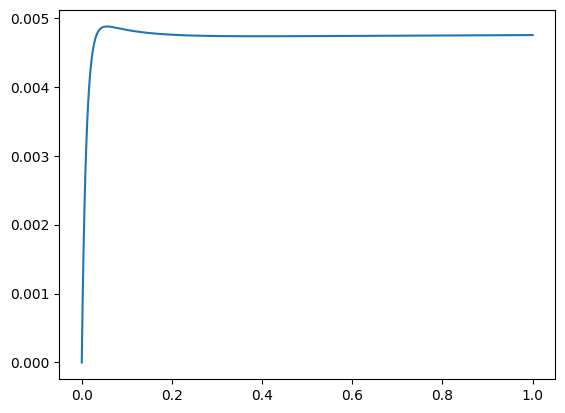

In [29]:
tlist = np.linspace(0,1,1000)
readout_0 = evolve_optical_pumping(rho_relaxed_0, H_0, 1, 1000, cops, PL_op)
plt.plot(tlist,readout_0.expect[0])

## Add in microwave for ground state spin transition

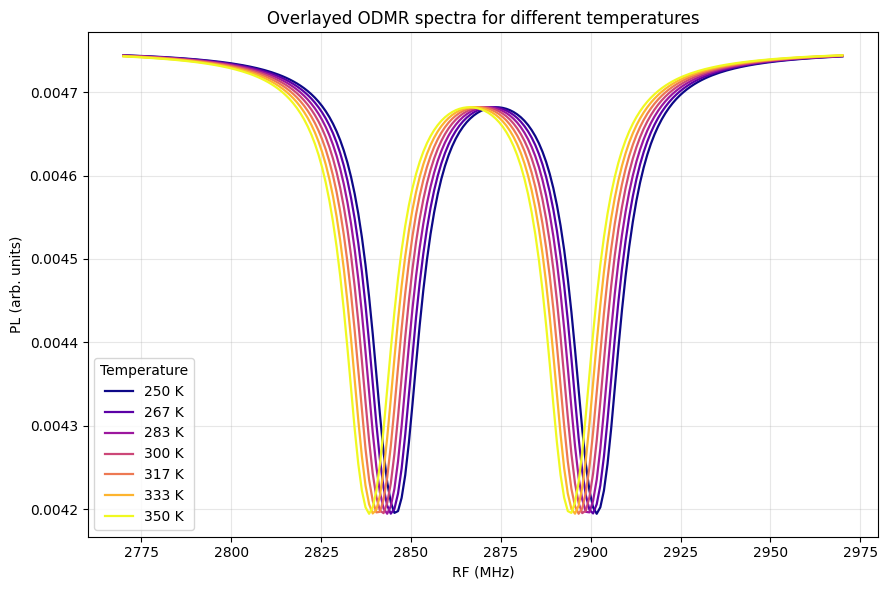

In [32]:
def D_of_T(T, D0=2870.0, T0=300.0, alpha=-0.074):
  """Linear model for zero-field splitting (MHz) vs temperature (K).
  alpha in MHz/K (default -0.074 MHz/K ~ -74 kHz/K)."""
  return D0 + alpha * (T - T0)


def T1_of_T(T, T1_0=1e6, T0=300.0, beta=0.01):
  """Phenomenological T1 (microseconds) vs T. Default T1_0=1e6 us (1 s)."""
  return T1_0 * np.exp(-beta * (T - T0))


def T2_of_T(T, T2_0=1e3, T0=300.0, gamma=0.005):
  """Phenomenological T2 (microseconds) vs T. Default T2_0=1e3 us (1 ms)."""
  return max(1.0, T2_0 * np.exp(-gamma * (T - T0)))


def NV_ODMR(BNV, RF_freq, rabi_rate, T=300.0):
  """Temperature-aware NV_ODMR.
  Builds H using D(T) and reconstructs T1/T2-dependent collapse operators.
  Returns PL readout (scalar) for the given RF frequency and temperature.
  """
  # zero-field splitting at temperature T (MHz)
  D = D_of_T(T)

  Delta_p = (D + 2.8 * BNV) - RF_freq
  Delta_m = (D - 2.8 * BNV) - RF_freq   # B field in Gauss
  Omega_m = rabi_rate
  Omega_p = rabi_rate

  H_rf = 2 * np.pi * (Delta_p * gs_p1 * gs_p1.dag()
            + Delta_m * gs_m1 * gs_m1.dag()
            + Omega_p / 2 * gs_0 * gs_p1.dag()
            + Omega_p / 2 * gs_p1 * gs_0.dag()
            + Omega_m / 2 * gs_0 * gs_m1.dag()
            + Omega_m / 2 * gs_m1 * gs_0.dag()
            + 4.708E8 * es_p1 * es_p1.dag()
            + 4.708E8 * es_0 * es_0.dag()
            + 4.708E8 * es_m1 * es_m1.dag()
            + 0.5 * 4.708E8 * shelf_state * shelf_state.dag())

  # Dynamic T1/T2 rates (units: 1/us)
  T1_us = T1_of_T(T)
  rate_T1_dyn = 1.0 / T1_us
  T2_us = T2_of_T(T)
  rate_deph = 1.0 / T2_us

  # Reconstruct T1-related collapse operators with temperature-dependent rates
  cop_01_dyn = np.sqrt(rate_T1_dyn) * gs_m1 * gs_0.dag()
  cop_12_dyn = np.sqrt(rate_T1_dyn) * gs_p1 * gs_m1.dag()
  cop_20_dyn = np.sqrt(rate_T1_dyn) * gs_0 * gs_p1.dag()
  cop_10_dyn = cop_01_dyn.dag()
  cop_21_dyn = cop_12_dyn.dag()
  cop_02_dyn = cop_20_dyn.dag()

  # Pure dephasing on ground states (phenomenological)
  cop_phi0 = np.sqrt(rate_deph) * gs_0 * gs_0.dag()
  cop_phim1 = np.sqrt(rate_deph) * gs_m1 * gs_m1.dag()
  cop_phip1 = np.sqrt(rate_deph) * gs_p1 * gs_p1.dag()

  # Build dynamic collapse list: use radiative/ISC/shelve operators already defined globally,
  # but replace the static T1 operators with the dynamic versions and add dephasing.
  dynamic_cops = [cop_03, cop_14, cop_25, cop_30, cop_41, cop_62, cop_47, cop_57, cop_67, cop_70, cop_72, cop_73,
          cop_01_dyn, cop_12_dyn, cop_20_dyn, cop_10_dyn, cop_21_dyn, cop_02_dyn,
          cop_phi0, cop_phim1, cop_phip1]

  readout = evolve_optical_pumping(rho_relaxed_0, H_rf, 1, 1000, dynamic_cops, PL_op)
  return readout.expect[0][-1]


# Example: temperature sweep for ODMR (compute PL vs RF for each temperature)
# Note: this can be computationally costly for dense grids; reduce points if needed.
temps = np.linspace(250, 350, 7)  # temperatures in K (will produce 7 overlayed curves)
RF_sweep = np.linspace(2770, 2970, 200)  # increase RF resolution slightly for smoother curves
PL_vs_T = np.zeros((len(temps), len(RF_sweep)))
BNV = 10  # Gauss (re-use from earlier; can be adjusted)
rabi_rate = 3  # MHz

for ti, T in enumerate(temps):
  for i, RF_freq in enumerate(RF_sweep):
    PL_vs_T[ti, i] = NV_ODMR(BNV, RF_freq, rabi_rate, T)

# Overlay plot: one curve per temperature
plt.figure(figsize=(9,6))
cmap = plt.get_cmap('plasma')
colors = [cmap(i/(len(temps)-1)) for i in range(len(temps))]
for ti, T in enumerate(temps):
  plt.plot(RF_sweep, PL_vs_T[ti], label=f"{T:.0f} K", color=colors[ti], linewidth=1.6)

plt.xlabel('RF (MHz)')
plt.ylabel('PL (arb. units)')
plt.title('Overlayed ODMR spectra for different temperatures')
plt.legend(title='Temperature')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: keep a quick heatmap for overview (uncomment to enable)
# plt.figure(figsize=(7,4))
# plt.imshow(PL_vs_T, aspect='auto', extent=[RF_sweep[0], RF_sweep[-1], temps[-1], temps[0]])
# plt.xlabel('RF (MHz)')
# plt.ylabel('Temperature (K)')
# plt.title('ODMR vs Temperature (PL) - heatmap')
# plt.colorbar(label='PL')
# plt.show()

## Generate ODMR

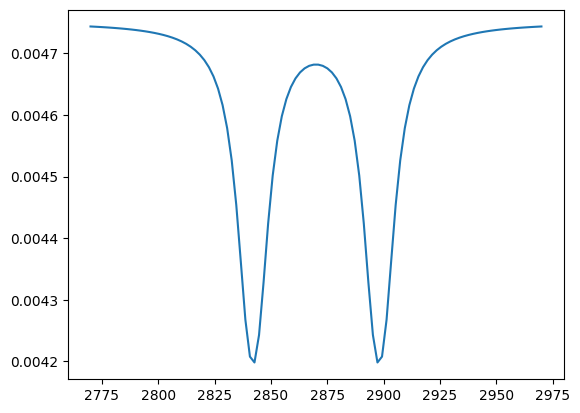

In [31]:
RF_sweep = np.linspace(2770,2970,100)
PL_vals = np.zeros(len(RF_sweep))
BNV = 10    # in Gauss
rabi_rate = 3    #MHz
for i, RF_freq in enumerate(RF_sweep):
  PL_vals[i] = NV_ODMR(BNV, RF_freq, rabi_rate)
plt.plot(RF_sweep,PL_vals)